# Battery Health Prognostics Baseline Evaluation (SoH & RUL)

This notebook evaluates two **baseline machine-learning models**

- **SoH (State of Health)** remaining capacity as a fraction of initial capacity
- **RUL (Remaining Useful Life)** number of cycles left before end-of-life (EOL)

The workflow is:

1. Load the frozen, leakage safe dataset
2. Train baseline Ridge and Random Forest models on the training cells
3. Evaluate on validation cells and **held-out, unseen test cells**
4. Visualize predicted-vs-actual performance
5. Rank test cells by prediction difficulty

## 1. Setup & Imports

Standard data-science stack: `pandas`/`numpy` for data handling, `scikit-learn` for modelling and metrics, `matplotlib`/`seaborn` for plots.

In [ ]:
import os, glob, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({'font.size': 11, 'figure.autolayout': True})

## 2. Load the Dataset

In [ ]:
v1_dir = "/content/dataset_v1_frozen"
data_file = os.path.join(v1_dir, "dataset_v1_cell_splits.npz")
meta_file = os.path.join(v1_dir, "dataset_v1_windows_metadata.csv")

if not os.path.exists(data_file):
    from google.colab import drive
    drive.mount('/content/drive')
    meta_path = [os.path.join(r, f) for r, d, fs in os.walk('/content') for f in fs if f == 'metadata.csv' and 'drive' not in r]
    if not meta_path:
        drive_zips = glob.glob('/content/drive/MyDrive/**/cleaned_dataset*.zip', recursive=True)
        if drive_zips:
            !unzip -o -q "{drive_zips[0]}" -d /content/
        meta_path = [os.path.join(r, f) for r, d, fs in os.walk('/content') for f in fs if f == 'metadata.csv' and 'drive' not in r]

    METADATA_PATH = meta_path[0]
    DATA_CSV_DIR = os.path.join(os.path.dirname(METADATA_PATH), 'data')
    df = pd.read_csv(METADATA_PATH)
    df['Capacity'] = pd.to_numeric(df['Capacity'].astype(str).str.replace(r'[\[\]]', '', regex=True), errors='coerce')
    dis_df = df[(df['type'] == 'discharge') & (df['Capacity'] > 0.05)].sort_values(['battery_id', 'test_id']).copy()

    c0 = dis_df.groupby('battery_id')['Capacity'].first()
    dis_df['initial_capacity'] = dis_df['battery_id'].map(c0)
    dis_df['SOH'] = dis_df['Capacity'] / dis_df['initial_capacity']

    def assign_rul(sub):
        eol = sub[sub['Capacity'] <= 0.70 * sub['initial_capacity'].iloc[0]]
        eol_cycle = eol['test_id'].iloc[0] if len(eol) > 0 else sub['test_id'].max()
        sub['RUL'] = np.maximum(0, eol_cycle - sub['test_id'])
        return sub
    dis_df = dis_df.groupby('battery_id', group_keys=False).apply(assign_rul)

    records = []
    for idx, r in dis_df.iterrows():
        f = os.path.join(DATA_CSV_DIR, r['filename'])
        if not os.path.exists(f): continue
        try:
            raw = pd.read_csv(f)
            if len(raw) < 10 or 'Time' not in raw or raw['Time'].iloc[-1] < 60: continue
            w = raw[raw['Time'] <= 500]
            if len(w) < 5: continue
            dt = w['Time'].iloc[-1] - w['Time'].iloc[0] + 1e-6
            records.append({
                'battery_id': r['battery_id'], 'test_id': int(r['test_id']),
                'ambient_temperature': r['ambient_temperature'],
                'feat_R_est': (w['Voltage_measured'].iloc[0] - w['Voltage_measured'].iloc[min(3, len(w)-1)]) / (abs(w['Current_measured'].iloc[min(3, len(w)-1)]) + 1e-6),
                'feat_dV_dt': (w['Voltage_measured'].iloc[-1] - w['Voltage_measured'].iloc[0]) / dt,
                'feat_dT_dt': (w['Temperature_measured'].iloc[-1] - w['Temperature_measured'].iloc[0]) / dt,
                'feat_V_mean': float(w['Voltage_measured'].mean()),
                'feat_T_mean': float(w['Temperature_measured'].mean()),
                'target_SOH': float(r['SOH']), 'target_RUL': float(r['RUL'])
            })
        except: pass
    feat_df = pd.DataFrame(records)
    test_cells = ['B0018', 'B0028', 'B0032', 'B0036', 'B0040', 'B0043', 'B0044', 'B0051', 'B0056']
    val_cells = ['B0007', 'B0027', 'B0031', 'B0034', 'B0039', 'B0042', 'B0048', 'B0050', 'B0054']

    train_df = feat_df[~feat_df['battery_id'].isin(test_cells + val_cells)]
    val_df = feat_df[feat_df['battery_id'].isin(val_cells)]
    test_df = feat_df[feat_df['battery_id'].isin(test_cells)]

    feat_cols = [c for c in feat_df.columns if c.startswith('feat_')]
    X_train, y_train_soh, y_train_rul = train_df[feat_cols].values, train_df['target_SOH'].values, train_df['target_RUL'].values
    X_val, y_val_soh, y_val_rul = val_df[feat_cols].values, val_df['target_SOH'].values, val_df['target_RUL'].values
    X_test, y_test_soh, y_test_rul = test_df[feat_cols].values, test_df['target_SOH'].values, test_df['target_RUL'].values
    test_meta = test_df[['battery_id', 'test_id', 'ambient_temperature']].reset_index(drop=True)
else:
    data = np.load(data_file)
    X_train = data['X_train'].reshape(len(data['X_train']), -1)
    y_train_soh = data['y_train_soh']
    y_train_rul = data['y_train_rul']
    X_val = data['X_val'].reshape(len(data['X_val']), -1)
    y_val_soh = data['y_val_soh']
    y_val_rul = data['y_val_rul']
    X_test = data['X_test'].reshape(len(data['X_test']), -1)
    y_test_soh = data['y_test_soh']
    y_test_rul = data['y_test_rul']
    meta_df = pd.read_csv(meta_file)
    test_cells = ['B0018', 'B0028', 'B0032', 'B0036', 'B0040', 'B0043', 'B0044', 'B0051', 'B0056']
    test_meta = meta_df[meta_df['battery_id'].isin(test_cells)].reset_index(drop=True)

Mounted at /content/drive


/tmp/ipykernel_3416/3391926078.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dis_df = dis_df.groupby('battery_id', group_keys=False).apply(assign_rul)


## 3. Evaluation Metrics

A small helper that returns the four standard regression metrics used throughout the project: **MAE**, **RMSE**, **MAPE (%)**, and **R²**.

In [ ]:
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-3, None))) * 100
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2}

## 4. Train Baseline Models

Two families of baseline model, one for each target:

- **Ridge Regression** —> a simple, well-regularized linear baseline
- **Random Forest Regressor** —> a stronger non-linear baseline (100 trees)

Both are trained only on `X_train` / the training cells' targets. The Random Forest predictions are what we evaluate below.

In [ ]:
models = {
    'SOH_Ridge': Ridge(alpha=1.0).fit(X_train, y_train_soh),
    'SOH_RF': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train_soh),
    'RUL_Ridge': Ridge(alpha=1.0).fit(X_train, y_train_rul),
    'RUL_RF': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train_rul)
}

## 5. Generate Predictions

Predict SoH and RUL on both the validation split and the fully unseen test cells, using the Random Forest models. RUL predictions are clipped at zero (a cell can't have negative remaining life).

In [ ]:
pred_val_soh = models['SOH_RF'].predict(X_val)
pred_test_soh = models['SOH_RF'].predict(X_test)
pred_val_rul = np.maximum(0, models['RUL_RF'].predict(X_val))
pred_test_rul = np.maximum(0, models['RUL_RF'].predict(X_test))

## 6. Results Table

Metrics for both targets (**SoH**, **RUL**), on both splits (**Validation**, **Test unseen cells**). The test-cell numbers are the ones that matter most: they show how well the model generalizes to batteries it never saw during training.

In [ ]:
results = [
    {'Target': 'SoH', 'Split': 'Validation', **calc_metrics(y_val_soh, pred_val_soh)},
    {'Target': 'SoH', 'Split': 'Test (Unseen Cells)', **calc_metrics(y_test_soh, pred_test_soh)},
    {'Target': 'RUL', 'Split': 'Validation', **calc_metrics(y_val_rul, pred_val_rul)},
    {'Target': 'RUL', 'Split': 'Test (Unseen Cells)', **calc_metrics(y_test_rul, pred_test_rul)}
]

metrics_df = pd.DataFrame(results)
print("="*65)
print("BASELINE PROGNOSTICS EVALUATION METRICS")
print("="*65)
display(metrics_df)

BASELINE PROGNOSTICS EVALUATION METRICS


,Target,Split,MAE,RMSE,MAPE(%),R2
0,SoH,Validation,6.572578,10.884249,1.355220e+03,-14.079186
1,SoH,Test (Unseen Cells),1.155127,3.000321,1.407197e+03,-24.401436
2,RUL,Validation,84.590797,114.214738,2.091888e+06,0.516721
3,RUL,Test (Unseen Cells),107.162545,144.274450,1.932430e+06,-0.388595


## 7. Predicted vs. Actual Test Cells


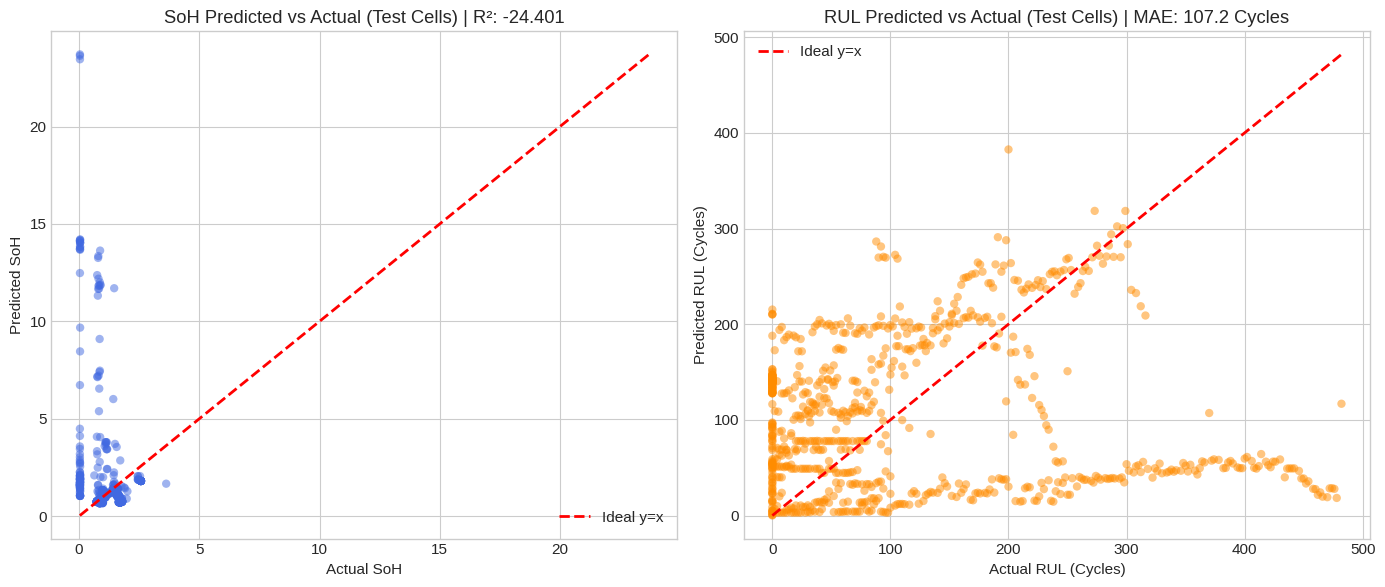

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test_soh, pred_test_soh, alpha=0.5, color='royalblue', edgecolors='none')
min_s, max_s = min(y_test_soh.min(), pred_test_soh.min()), max(y_test_soh.max(), pred_test_soh.max())
axes[0].plot([min_s, max_s], [min_s, max_s], 'r--', lw=2, label='Ideal y=x')
axes[0].set_title(f"SoH Predicted vs Actual (Test Cells) | R²: {calc_metrics(y_test_soh, pred_test_soh)['R2']:.3f}")
axes[0].set_xlabel("Actual SoH")
axes[0].set_ylabel("Predicted SoH")
axes[0].legend()

axes[1].scatter(y_test_rul, pred_test_rul, alpha=0.5, color='darkorange', edgecolors='none')
min_r, max_r = min(y_test_rul.min(), pred_test_rul.min()), max(y_test_rul.max(), pred_test_rul.max())
axes[1].plot([min_r, max_r], [min_r, max_r], 'r--', lw=2, label='Ideal y=x')
axes[1].set_title(f"RUL Predicted vs Actual (Test Cells) | MAE: {calc_metrics(y_test_rul, pred_test_rul)['MAE']:.1f} Cycles")
axes[1].set_xlabel("Actual RUL (Cycles)")
axes[1].set_ylabel("Predicted RUL (Cycles)")
axes[1].legend()

plt.show()

## 8. Per Cell Modelling Difficulty


In [ ]:
test_meta['Actual_SOH'] = y_test_soh
test_meta['Pred_SOH'] = pred_test_soh
test_meta['SOH_Error'] = np.abs(y_test_soh - pred_test_soh)
test_meta['Actual_RUL'] = y_test_rul
test_meta['Pred_RUL'] = pred_test_rul
test_meta['RUL_Error'] = np.abs(y_test_rul - pred_test_rul)

cell_difficulty = test_meta.groupby('battery_id').agg({
    'ambient_temperature': 'first',
    'SOH_Error': 'mean',
    'RUL_Error': 'mean',
    'Actual_RUL': 'count'
}).rename(columns={'Actual_RUL': 'Cycle_Count'}).sort_values(by='RUL_Error', ascending=False).reset_index()

print("="*65)
print("MODELLING DIFFICULTY RANKING BY TEST CELL")
print("="*65)
display(cell_difficulty)

MODELLING DIFFICULTY RANKING BY TEST CELL


,battery_id,ambient_temperature,SOH_Error,RUL_Error,Cycle_Count
0,B0036,24,0.845559,206.319188,197
1,B0056,4,0.371069,98.782549,102
2,B0043,22,2.201800,92.935185,108
3,B0044,22,3.640607,78.127870,108
4,B0051,4,0.220854,66.260000,24
5,B0028,24,0.023677,62.491429,28
6,B0040,24,1.184124,59.543404,47
7,B0018,24,0.023394,57.983106,132
8,B0032,43,0.195499,31.048500,40


## 9. RUL Error by Test Cell Bar Chart

A quick visual ranking of which unseen test cells the model struggles with most, in terms of mean absolute RUL error (in cycles).

/tmp/ipykernel_3416/2193526701.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cell_difficulty, x='battery_id', y='RUL_Error', palette='Reds_r')


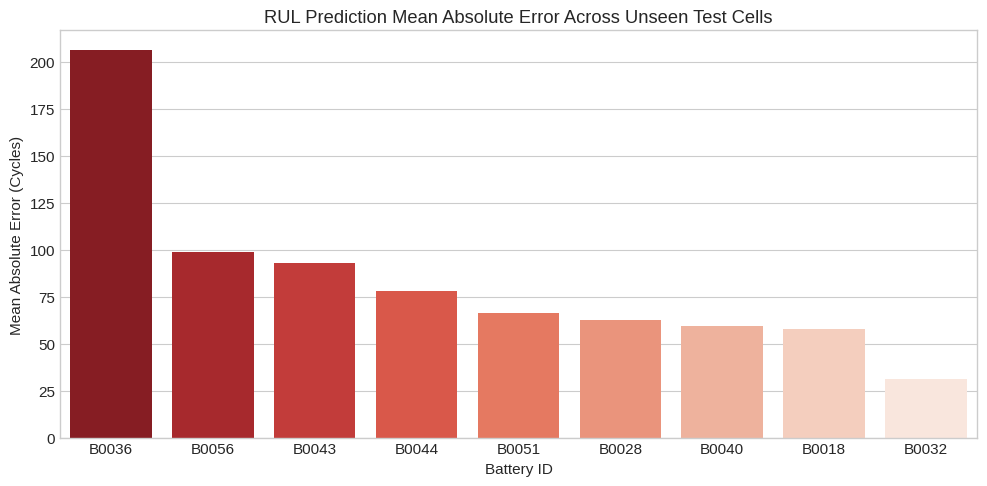

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=cell_difficulty, x='battery_id', y='RUL_Error', palette='Reds_r')
plt.title("RUL Prediction Mean Absolute Error Across Unseen Test Cells")
plt.xlabel("Battery ID")
plt.ylabel("Mean Absolute Error (Cycles)")
plt.show()

## Summary

- Two baseline models (Ridge, Random Forest) were trained for **SoH** and **RUL** prediction using a small set of hand-crafted per-window features.
- Evaluation followed a strict **group split by `battery_id`** — the test cells were never seen in training, giving a realistic estimate of generalization.
- The metrics table, scatter plots, and per-cell difficulty ranking together give both an aggregate and a cell-by-cell view of baseline performance, forming a reference point against which the Day 5 deep-learning models (LSTM/GRU, 1D-CNN, Transformer) can be compared.